In [7]:
from google.colab import files
uploaded = files.upload()


Saving loan_approval_dataset.csv to loan_approval_dataset (1).csv


In [8]:
import numpy as np
import pandas as pd

df = pd.read_csv('loan_approval_dataset.csv')

In [9]:
df.columns=df.columns.str.strip()
df.columns

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')

In [10]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [11]:
df.shape

(4269, 13)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [13]:
df.size

55497

In [14]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [15]:
#x--> column
#y--> row
#In this x is predict and y is the data after we remove the target to avoid data leakage
x=df.drop('loan_status',axis=1)
y=df['loan_status']
print(x.columns)

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value'],
      dtype='object')


In [16]:
# Chacking the missing values
df.isnull().sum()

,0
loan_id,0
no_of_dependents,0
education,0
self_employed,0
income_annum,0
loan_amount,0
loan_term,0
cibil_score,0
residential_assets_value,0
commercial_assets_value,0


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (3415, 12)
Shape of X_test: (854, 12)
Shape of y_train: (3415,)
Shape of y_test: (854,)


In [18]:
X_train.shape

(3415, 12)

In [19]:
# To Check the stratify
y_train.value_counts()


,count
loan_status,
Approved,2125
Rejected,1290


In [20]:
#In percentage

y_train.value_counts(normalize=True)

,proportion
loan_status,
Approved,0.622255
Rejected,0.377745


In [21]:
y_test.value_counts()

,count
loan_status,
Approved,531
Rejected,323


In [22]:
y_test.value_counts(normalize=True)

,proportion
loan_status,
Approved,0.62178
Rejected,0.37822


In [23]:
#to check the data type
X_train.dtypes

,0
loan_id,int64
no_of_dependents,int64
education,object
self_employed,object
income_annum,int64
loan_amount,int64
loan_term,int64
cibil_score,int64
residential_assets_value,int64
commercial_assets_value,int64


In [24]:
#loan id ==> Just for identifer to remove that we used drop model(remove uncessary columns)
X_train=X_train.drop('loan_id',axis=1, errors='ignore')
X_test=X_test.drop('loan_id',axis=1, errors='ignore')

In [25]:
# removed loan id column
X_train.dtypes


,0
no_of_dependents,int64
education,object
self_employed,object
income_annum,int64
loan_amount,int64
loan_term,int64
cibil_score,int64
residential_assets_value,int64
commercial_assets_value,int64
luxury_assets_value,int64


In [26]:
# encoding the model x train and x test
# one hot encode categorical feature
# encoding ==> converting values categorical values in numerical values
from sklearn.preprocessing import OneHotEncoder

categorical_columns = ['education','self_employed']
encoder = OneHotEncoder(drop='first',sparse_output=False)
X_train_cat = encoder.fit_transform(X_train[categorical_columns])
X_test_cat = encoder.transform(X_test[categorical_columns])

# the drop is to remove the first column to avoid dummy variable trap
# sparse in default would store them as a numpy np.array
# if false itll give the encoded data as normal table of numbers instead compressing if

In [27]:
X_train_cat.shape

(3415, 2)

In [28]:
X_test_cat.shape

(854, 2)

In [29]:
np.unique(X_train_cat[0])

array([0., 1.])

In [30]:
encoder.get_feature_names_out(categorical_columns)

array(['education_ Not Graduate', 'self_employed_ Yes'], dtype=object)

In [31]:
encoder.categories_

[array([' Graduate', ' Not Graduate'], dtype=object),
 array([' No', ' Yes'], dtype=object)]

In [32]:
# Scaling numeric features
#Scaling
# Scaling is the process of adjusting the range of features (numerical input variables) to a standard scale.
from sklearn.preprocessing import StandardScaler
numeric_columns = X_train.drop(categorical_columns, axis=1).columns
scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train[numeric_columns])
X_test_num = scaler.transform(X_test[numeric_columns])

In [33]:
X_train_num_df = pd.DataFrame(X_train_num, columns=numeric_columns, index=X_train.index)
X_train_num_df.head()

,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
1224,-1.456965,1.700955,0.983585,0.549181,-0.806352,-0.995573,1.942808,0.659076,0.696034
478,0.305326,-0.514765,-0.717129,-0.500709,1.110842,-0.312884,0.216625,-0.582560,0.078226
3065,-0.282104,-1.086564,-1.228455,0.549181,-0.557291,-0.390463,-0.796070,-1.066029,-1.126500
326,-0.282104,-0.407553,-0.417003,0.199218,-0.476201,-0.669744,-1.141306,-0.516632,-0.107117
2991,0.305326,-0.979352,-0.728245,0.199218,-0.238724,-0.592166,-0.819085,-0.978125,-1.126500


In [34]:
X_train_num_df.std()

,0
no_of_dependents,1.000146
income_annum,1.000146
loan_amount,1.000146
loan_term,1.000146
cibil_score,1.000146
residential_assets_value,1.000146
commercial_assets_value,1.000146
luxury_assets_value,1.000146
bank_asset_value,1.000146


In [35]:
X_train_num_df.mean()

,0
no_of_dependents,1.430448e-16
income_annum,-8.530674e-17
loan_amount,8.530674e-17
loan_term,-1.924603e-16
cibil_score,-2.642428e-16
residential_assets_value,4.369370e-17
commercial_assets_value,-1.248391e-17
luxury_assets_value,-1.040326e-16
bank_asset_value,1.316013e-16


In [36]:
X_train_num_df.min(), X_train_num_df.max()

(no_of_dependents           -1.456965
 income_annum               -1.729838
 loan_amount                -1.639738
 loan_term                  -1.550599
 cibil_score                -1.727300
 residential_assets_value   -1.166245
 commercial_assets_value    -1.141306
 luxury_assets_value        -1.626413
 bank_asset_value           -1.528075
 dtype: float64,
 no_of_dependents            1.480187
 income_annum                1.736692
 loan_amount                 2.717647
 loan_term                   1.599072
 cibil_score                 1.747975
 residential_assets_value    3.302260
 commercial_assets_value     3.323755
 luxury_assets_value         2.647892
 bank_asset_value            3.012814
 dtype: float64)

In [37]:
df.shape

(4269, 13)

In [38]:
x.shape

(4269, 12)

In [39]:
X_train.shape

(3415, 11)

In [40]:
X_train_num_df.shape

(3415, 9)

In [41]:
X_train_cat.shape

(3415, 2)

In [42]:
#feature combination or concatenate

X_train_final = np.concatenate([X_train_num_df, X_train_cat], axis=1)
X_test_final = np.concatenate([X_test_num, X_test_cat], axis=1)

In [43]:
X_train_final.shape

(3415, 11)

In [44]:
X_test_final.shape

(854, 11)

In [45]:
# Logistic Regression Model
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train_final, y_train)


LogisticRegression()

In [46]:
# Evaluate accuracy

from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test_final)
accuracy_score(y_test, y_pred)


0.9227166276346604

In [47]:
recap=pd.DataFrame({'y_test':y_test,'y_pred':y_pred})
recap.head(10)


,y_test,y_pred
2346,Approved,Approved
1162,Approved,Approved
3061,Approved,Approved
483,Rejected,Approved
2102,Approved,Approved
1002,Rejected,Rejected
792,Rejected,Approved
2870,Approved,Approved
2475,Approved,Approved
3867,Approved,Approved


In [48]:
# Problem traming
# EDA
# data quality check: checking missing values
# feature target separation
# train test split
# feature type identification
# removing unnecessary columns
# categorical feature encoding
# numerical feature scaling
# feature combination
# model training
# model evaluation

In [49]:
x=df[['education']]
x.head()

,education
0,Graduate
1,Not Graduate
2,Graduate
3,Graduate
4,Not Graduate


In [50]:
df.columns

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')

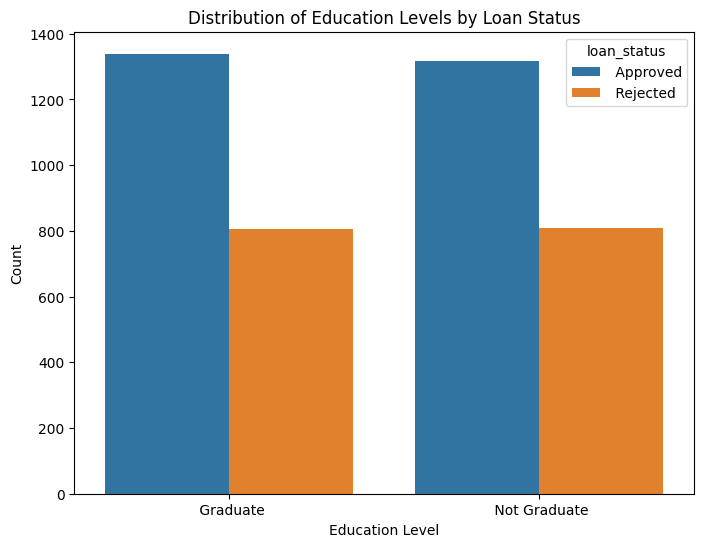

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(x='education', hue='loan_status', data=df)
plt.title('Distribution of Education Levels by Loan Status')
plt.xlabel('Education Level')
plt.ylabel('Count')
# plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

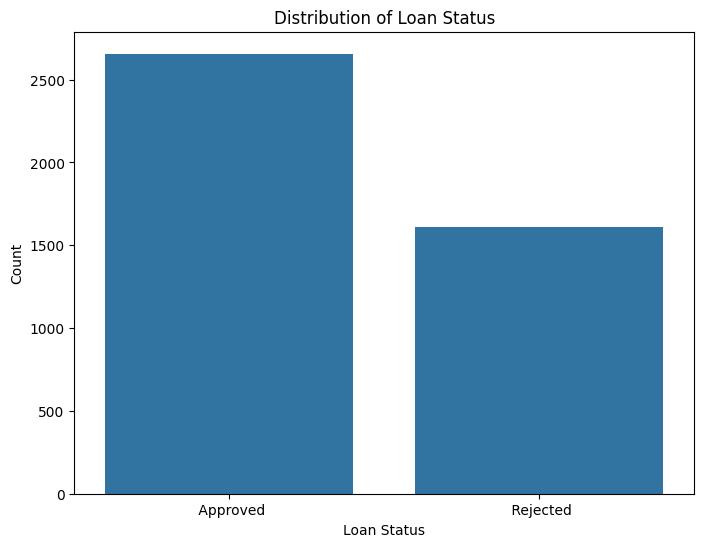

In [52]:
# Bar Chart of loan Status

plt.figure(figsize=(8, 6))
sns.countplot(x='loan_status', data=df)
plt.title('Distribution of Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.show()

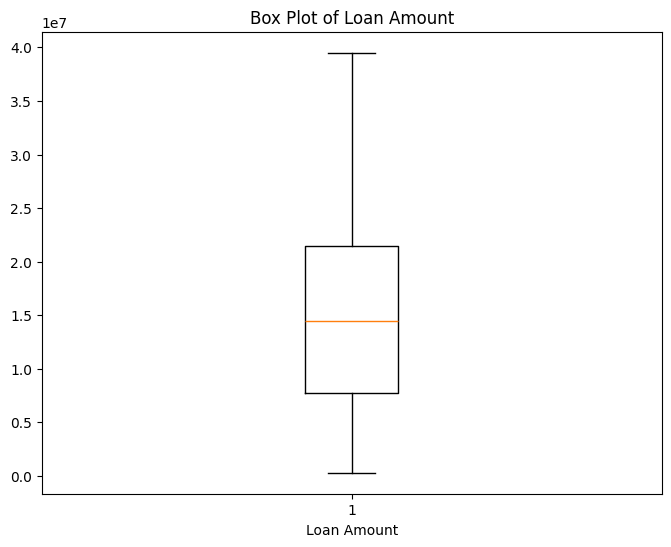

In [53]:
# Box Plot for loan Amount

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
plt.boxplot(x=df['loan_amount'])
plt.title('Box Plot of Loan Amount')
plt.xlabel('Loan Amount')
plt.show()

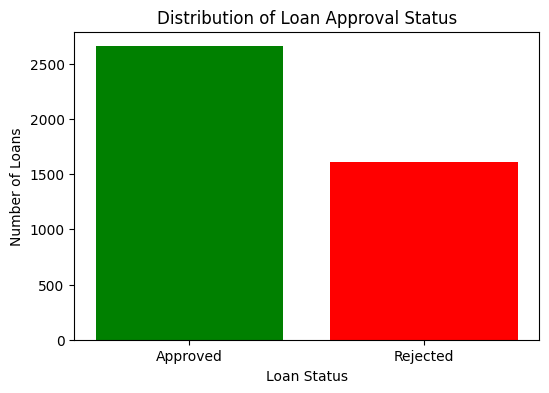

In [58]:
#which group has higher loan approval

approved_loans = df[df['loan_status'].str.strip() == 'Approved'].shape[0]
rejected_loans = df[df['loan_status'].str.strip() == 'Rejected'].shape[0]

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.bar(['Approved', 'Rejected'], [approved_loans, rejected_loans], color=['green', 'red'])
plt.xlabel('Loan Status')
plt.ylabel('Number of Loans')
plt.title('Distribution of Loan Approval Status')
plt.show()

In [65]:
display(x['education'].value_counts())

,count
education,
Graduate,2144
Not Graduate,2125


/tmp/ipython-input-2902730445.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='loan_status', y='cibil_score', data=df, palette='viridis')


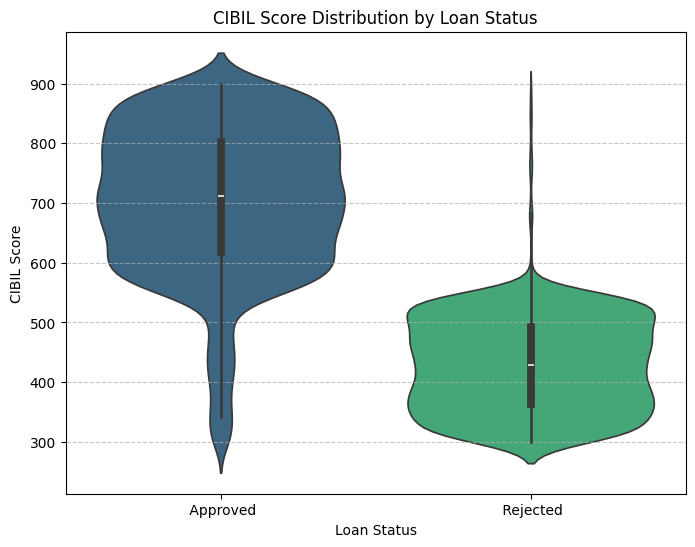

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.violinplot(x='loan_status', y='cibil_score', data=df, palette='viridis')
plt.title('CIBIL Score Distribution by Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('CIBIL Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [56]:
print("Features (X) head:")
display(x.head())
print("Features (X) shape:")
print(x.shape)

Features (X) head:


,education
0,Graduate
1,Not Graduate
2,Graduate
3,Graduate
4,Not Graduate


Features (X) shape:
(4269, 1)


In [61]:
print("Target (Y) head:")
display(y.head())
print("Target (Y) shape:")
print(y.shape)

Target (Y) head:


,loan_status
0,Approved
1,Rejected
2,Rejected
3,Rejected
4,Rejected


Target (Y) shape:
(4269,)
